<a href="https://colab.research.google.com/github/lytyler/ST554_Homework5/blob/main/Homework5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Lanette Tyler   
Homework 5     
ST554  
Spring 2026

# Part I - Concepts

## 1. Five V's of Big Data


I used to teach childbirth classes, and one of the topics covered was routine procedures during childbirth. One routine procedure is **continuous electronic fetal monitoring**. This technology is used with most births, even though it was never scientifically established to improve outcomes. Major studies in the past have indicated either no difference in outcomes between large groups of mothers and babies monitored continuously compared to those who were monitored intermittently, or worse outcomes for the continuously monitored group. This is old information, but the practice continues. A recent [New York Times article](https://www.nytimes.com/2025/11/06/health/electronic-fetal-monitoring-c-sections.html) covered the topic. People seem to be for or against the use of fetal monitoring, but I think some good analysis of the data could help us use it better than we currently do. There is no clear universal standard or set of standards for what constitues fetal distress as picked up by the monitoring - it varies with doctors, practices, hospitals, and regions. With regard to the 5 V's of Big Data:
*   **Volume:** With regard to volume of data, a study to help establish guidelines for what constitutes fetal distress as indicated by continuous elctronic fetal monitoring during childbirth would need to contain many, many observations. A Cochrane review in 2017 of 12 previous studies dating as far back as the 1970's and 1980's included 37,000 participants. Considering that most births for several decades have included use of the technology, as well as the importance of widespread maternal and fetal health during childbirth, this could be and would need to be a large study indeed.
*   **Variety:** This would not be data that would fit easily into a 2D table. Continuous electronic fetal monitoring involves tracking the fetal heartbeat as well as contraction strength over the course of labor, so two ongoing, continuous measurements over time. The heart rate matters, as well as the response of the heart rate to the contractions. I believe the point in labor also matters for the range of acceptable heart rates.
*   **Velocity:** How the speed of the data coming in would affect the management and analysis of the data would depend on how the study is set up. It seems to me that doing it in batches would work, updating data from participating hopsitals periodically. This might also be better for collecting other relevant data about the birth. If historic data is used then velocity would not be an issue.
*   **Veracity:** As I understand it annecdotally, there is a great amount of variability in what sorts of heart rates and heart rate patterns produce what kinds of birth outcomes.
*   **Value:** Making birth safer for mothers and babies is of great value. US maternal and fetal birth outcomes compare poorly to other rich nations.

## 2. **CRUD** Acronym (**C**reate, **R**ead, **U**pdate, and **D**elete Data)


The CRUD acronym stands for creating, reading, updating, and deleting data. Examples of these actions from the Lahman database in HW5: Part 4 are listed below:
*   **Create:** Data is not created in the homework assignment. No new tables are added to the database.
*   **Read:** Data is being read (and reported/displayed) from the database throughout the assignment. One specific example is number 9, returning "all the teams that played in the year 2015 with all of the corresponding columns from the Teams table."
*   **Update:** Data is not being updated within the database. No new observations are added, and no existing observations are modified. A new variable is created and reported in the third part of number 13 "create a new variable that is the win/loss percentage (W/(W+L))."
*   **Delete:** No data is deleted from the database.

## 3. Purpose of the HAVING clause in SQL code

The HAVING clause is an option of the SELECT statement. It is used after a GROUP BY clause. The HAVING clause specifies a condition with which to filter the groups. Only groups that meet the condition are reported. It is in contrast to the WHERE clause which is applied to the the observations and does not required a GROUP BY clause, and precedes the GROUP BY clause if there is one.

# Part II - Simulation of a Sampling Distribution for a SLR model

## Start with given code

In [1]:
#import modules
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import default_rng

In [2]:
#name, define, and set seed for random number generator, set betas for SLR model
rng = default_rng(32)
beta_0 = 7
beta_1 = 1.5

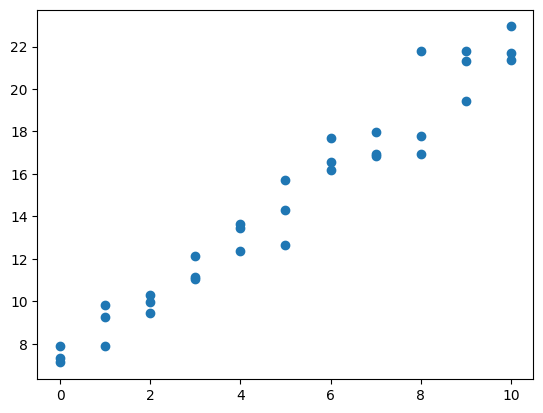

In [3]:
#get three 'values' of x at each integer from 0 to 10
x = np.array(list(np.linspace(start = 0, stop = 10, num = 11))*3)
n = 33

#create the 'responses' modeled from the line plus a random deviation
y = beta_0 + beta_1*x + rng.standard_normal(n)

#visualize the data
plt.scatter(x = x, y = y)
#plt.show()

## Use sklearn to obtain estimated slope

In [4]:
#import module
from sklearn import linear_model

In [5]:
#create a regression object
reg = linear_model.LinearRegression()

#fit regression model
reg.fit(x.reshape(-1, 1), y)

#extract slope
print(reg.coef_)

#add slope to slope_list
slope_list = []
slope_list.append(reg.coef_)
print(slope_list)

[1.47450564]
[array([1.47450564])]


## Repeat slope estimation 5000 times

In [6]:
#repeat 5000 times to create list of 5000 estimated slopes
for i in range(0, 5000):
    y = beta_0 + beta_1*x + rng.standard_normal(n)
    reg.fit(x.reshape(-1, 1), y)
    slope_list.append(reg.coef_)

## Create histogram of slope values

Text(0, 0.5, 'Frequency')

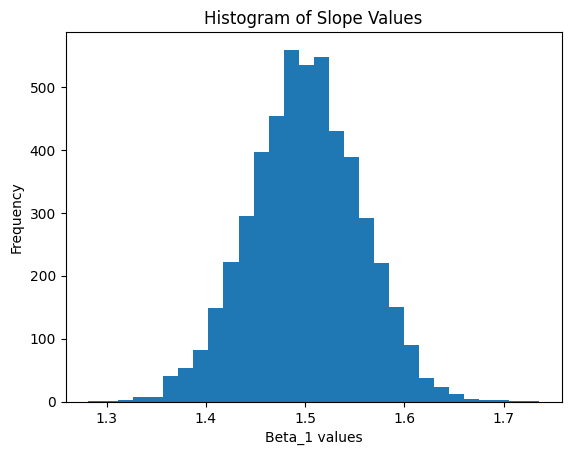

In [22]:
plt.hist(np.asarray(slope_list), bins = 30)
plt.title("Histogram of Slope Values")
plt.xlabel("Beta_1 values")
plt.ylabel("Frequency")